<a href="https://colab.research.google.com/github/cewgs/data-quality-and-wrangling-/blob/main/data_wrangling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data and Imports

In [30]:
!pip install RapidFuzz

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re
from scipy.stats import shapiro, boxcox
from functools import reduce
from rapidfuzz import fuzz
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import BernoulliRBM
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

In [32]:
# Data
# "https://www.kaggle.com/datasets/unsdsn/world-happiness"

df2015 = pd.read_csv("https://raw.githubusercontent.com/cewgs/data-quality-and-wrangling-/refs/heads/main/world%20happiness%20report%20files/2015.csv")
df2016 = pd.read_csv("https://raw.githubusercontent.com/cewgs/data-quality-and-wrangling-/refs/heads/main/world%20happiness%20report%20files/2016.csv")
df2017 = pd.read_csv("https://raw.githubusercontent.com/cewgs/data-quality-and-wrangling-/refs/heads/main/world%20happiness%20report%20files/2017.csv")
df2018 = pd.read_csv("https://raw.githubusercontent.com/cewgs/data-quality-and-wrangling-/refs/heads/main/world%20happiness%20report%20files/2018.csv")
df2019 = pd.read_csv("https://raw.githubusercontent.com/cewgs/data-quality-and-wrangling-/refs/heads/main/world%20happiness%20report%20files/2019.csv")


# Structuring

Rough structure of the data: # Happiness Rank and Scores by Country (2015) — Feature Description

| Feature Name | Description |
|---------------|-------------|
| Country | Name of the country. |
| Region | Region the country belongs to. |
| Happiness Rank | Rank of the country based on the Happiness Score. |
| Happiness Score | A metric measured in 2015 by asking the sampled people the question: “How would you rate your happiness on a scale of 0 to 10 where 10 is the happiest.” |
| Standard Error | The standard error of the happiness score. |
| Economy (GDP per Capita) | The extent to which GDP contributes to the calculation of the Happiness Score. |
| Family | The extent to which Family contributes to the calculation of the Happiness Score. |
| Health (Life Expectancy) | The extent to which Life expectancy contributed to the calculation of the Happiness Score. |
| Freedom | The extent to which Freedom contributed to the calculation of the Happiness Score. |
| Trust (Government Corruption) | The extent to which Perception of Corruption contributes to the Happiness Score. |


In [33]:
# columns and head of the first file
display(df2015.head())
print(f"\n the shape is: {df2015.shape}")

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176



 the shape is: (158, 12)


In [34]:
# check if all dfs have the same columns
dataframes = [df2015, df2016, df2017, df2018, df2019]
if all([set(dataframes[0].columns) == set(df.columns) for df in dataframes]):
    print('All have the same columns \n ')
    print(f'{df2015.columns}')
else:
    print('Some have different columns: \n')

    for i, df in enumerate(dataframes):
      print(f"File {i+1}:")
      print(df.columns.tolist())
      print()

Some have different columns: 

File 1:
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

File 2:
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

File 3:
['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']

File 4:
['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

File 5:
['Overall rank', 'Country or re

In [35]:
for df in dataframes:
  display(df.head())

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596


,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340
2,3,Denmark,7.555,1.351,1.590,0.868,0.683,0.284,0.408
3,4,Iceland,7.495,1.343,1.644,0.914,0.677,0.353,0.138
4,5,Switzerland,7.487,1.420,1.549,0.927,0.660,0.256,0.357


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [36]:
# checking values for "Country and Region" in File 4 and 5,  only countries, no regions
print(f" file 1: \n {df2018["Country or region"].unique()} \n")
print(f"  file 2: {df2019["Country or region"].unique()}")

 file 1: 
 ['Finland' 'Norway' 'Denmark' 'Iceland' 'Switzerland' 'Netherlands'
 'Canada' 'New Zealand' 'Sweden' 'Australia' 'United Kingdom' 'Austria'
 'Costa Rica' 'Ireland' 'Germany' 'Belgium' 'Luxembourg' 'United States'
 'Israel' 'United Arab Emirates' 'Czech Republic' 'Malta' 'France'
 'Mexico' 'Chile' 'Taiwan' 'Panama' 'Brazil' 'Argentina' 'Guatemala'
 'Uruguay' 'Qatar' 'Saudi Arabia' 'Singapore' 'Malaysia' 'Spain'
 'Colombia' 'Trinidad & Tobago' 'Slovakia' 'El Salvador' 'Nicaragua'
 'Poland' 'Bahrain' 'Uzbekistan' 'Kuwait' 'Thailand' 'Italy' 'Ecuador'
 'Belize' 'Lithuania' 'Slovenia' 'Romania' 'Latvia' 'Japan' 'Mauritius'
 'Jamaica' 'South Korea' 'Northern Cyprus' 'Russia' 'Kazakhstan' 'Cyprus'
 'Bolivia' 'Estonia' 'Paraguay' 'Peru' 'Kosovo' 'Moldova' 'Turkmenistan'
 'Hungary' 'Libya' 'Philippines' 'Honduras' 'Belarus' 'Turkey' 'Pakistan'
 'Hong Kong' 'Portugal' 'Serbia' 'Greece' 'Lebanon' 'Montenegro' 'Croatia'
 'Dominican Republic' 'Algeria' 'Morocco' 'China' 'Azerbaijan'
 'Ta

In [37]:
# Creating a dictionary for differently named columns across dfs
column_names = {
    'Country': ['Country', 'Country or region'],
    'HappinessScore': ['Happiness Score', 'Happiness.Score', 'Score'],
    'HappinessRank': ['Happiness Rank', 'Overall rank', 'Happiness.Rank'],
    'LifeExpectancy': ['Health (Life Expectancy)', 'Health..Life.Expectancy.', 'Healthy life expectancy'],
    'Freedom': ['Freedom to make life choices', 'Freedom'],
    'Corruption': ['Trust (Government Corruption)', 'Perceptions of corruption', 'Trust..Government.Corruption','Trust..Government.Corruption.'],
    'SocialSupport': ['Family', 'Social support'],
    'Log_GDP_Capita': ['GDP per capita','Economy..GDP.per.Capita.', 'Economy (GDP per Capita)'],
    'LowerConfidenceInterval': ['Lower Confidence Interval', 'Whisker.low'],
    'UpperConfidenceInterval': ['Upper Confidence Interval', 'Whisker.high'],
    'DystopiaResidual': ['Dystopia.Residual', 'Dystopia Residual']
}

# Rename columns
for df in dataframes:
    rename_map = {}
    for new_name, variants in column_names.items():
        for variant in variants:
            if variant in df.columns:
                rename_map[variant] = new_name
                break

    df.rename(columns=rename_map, inplace=True)
print(df2015.columns)
print(df2016.columns)
print(df2017.columns)
print(df2018.columns)
print(df2019.columns)

Index(['Country', 'Region', 'HappinessRank', 'HappinessScore',
       'Standard Error', 'Log_GDP_Capita', 'SocialSupport', 'LifeExpectancy',
       'Freedom', 'Corruption', 'Generosity', 'DystopiaResidual'],
      dtype='object')
Index(['Country', 'Region', 'HappinessRank', 'HappinessScore',
       'LowerConfidenceInterval', 'UpperConfidenceInterval', 'Log_GDP_Capita',
       'SocialSupport', 'LifeExpectancy', 'Freedom', 'Corruption',
       'Generosity', 'DystopiaResidual'],
      dtype='object')
Index(['Country', 'HappinessRank', 'HappinessScore', 'UpperConfidenceInterval',
       'LowerConfidenceInterval', 'Log_GDP_Capita', 'SocialSupport',
       'LifeExpectancy', 'Freedom', 'Generosity', 'Corruption',
       'DystopiaResidual'],
      dtype='object')
Index(['HappinessRank', 'Country', 'HappinessScore', 'Log_GDP_Capita',
       'SocialSupport', 'LifeExpectancy', 'Freedom', 'Generosity',
       'Corruption'],
      dtype='object')
Index(['HappinessRank', 'Country', 'HappinessScore',

In [38]:
# add a years column
years = [2015, 2016, 2017, 2018, 2019]
for df_year_loop, year in zip(dataframes, years):
    df_year_loop['Year'] = year

# Substring extraction, first word of country name (e.g. labelling)
df["Country_Short"] = df["Country"].str.split().str[0]

# Column combination: composite key
df["Country_Year"] = df["Country"].str.replace(" ", "_") + "_" + df["Year"].astype(str)

display(df["Country_Year"].head())

,Country_Year
0,Finland_2019
1,Denmark_2019
2,Norway_2019
3,Iceland_2019
4,Netherlands_2019


In [39]:
# region like 'Western Europe' only present in 2 dfs
# create a mapping based on country and region, create new column "Region" for the other 3
region_map = df2015.set_index("Country")["Region"].to_dict()
for df in df2017, df2018, df2019:
    df["Region"] = df["Country"].map(region_map)

# concate
df = pd.concat(dataframes, ignore_index=True, sort=True)

print(f"check if new columns are there: \n {df2015.columns}")
display(df.head())
print(f"\n the shape is {df.shape}")


check if new columns are there: 
 Index(['Country', 'Region', 'HappinessRank', 'HappinessScore',
       'Standard Error', 'Log_GDP_Capita', 'SocialSupport', 'LifeExpectancy',
       'Freedom', 'Corruption', 'Generosity', 'DystopiaResidual', 'Year'],
      dtype='object')


,Corruption,Country,Country_Short,Country_Year,DystopiaResidual,Freedom,Generosity,HappinessRank,HappinessScore,LifeExpectancy,Log_GDP_Capita,LowerConfidenceInterval,Region,SocialSupport,Standard Error,UpperConfidenceInterval,Year
0,0.41978,Switzerland,NaN,NaN,2.51738,0.66557,0.29678,1,7.587,0.94143,1.39651,NaN,Western Europe,1.34951,0.03411,NaN,2015
1,0.14145,Iceland,NaN,NaN,2.70201,0.62877,0.43630,2,7.561,0.94784,1.30232,NaN,Western Europe,1.40223,0.04884,NaN,2015
2,0.48357,Denmark,NaN,NaN,2.49204,0.64938,0.34139,3,7.527,0.87464,1.32548,NaN,Western Europe,1.36058,0.03328,NaN,2015
3,0.36503,Norway,NaN,NaN,2.46531,0.66973,0.34699,4,7.522,0.88521,1.45900,NaN,Western Europe,1.33095,0.03880,NaN,2015
4,0.32957,Canada,NaN,NaN,2.45176,0.63297,0.45811,5,7.427,0.90563,1.32629,NaN,North America,1.32261,0.03553,NaN,2015



 the shape is (782, 17)


#Profiling

In [40]:
df.describe()

,Corruption,DystopiaResidual,Freedom,Generosity,HappinessRank,HappinessScore,LifeExpectancy,Log_GDP_Capita,LowerConfidenceInterval,SocialSupport,Standard Error,UpperConfidenceInterval,Year
count,781.000000,470.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,312.000000,782.000000,158.000000,312.000000,782.000000
mean,0.125436,2.092717,0.411091,0.218576,78.698210,5.379018,0.612416,0.916047,5.269139,1.078392,0.047885,5.467245,2016.993606
std,0.105816,0.565772,0.152880,0.122321,45.182384,1.127456,0.248309,0.407340,1.144780,0.329548,0.017146,1.125895,1.417364
min,0.000000,0.328580,0.000000,0.000000,1.000000,2.693000,0.000000,0.000000,2.521116,0.000000,0.018480,2.864884,2015.000000
25%,0.054000,1.737975,0.309768,0.130000,40.000000,4.509750,0.440183,0.606500,4.366000,0.869363,0.037268,4.551835,2016.000000
50%,0.091000,2.094640,0.431000,0.201982,79.000000,5.322000,0.647310,0.982205,5.211295,1.124735,0.043940,5.394889,2017.000000
75%,0.156030,2.455575,0.531000,0.278832,118.000000,6.189500,0.808000,1.236187,6.086750,1.327250,0.052300,6.382650,2018.000000
max,0.551910,3.837720,0.724000,0.838075,158.000000,7.769000,1.141000,2.096000,7.479556,1.644000,0.136930,7.669000,2019.000000


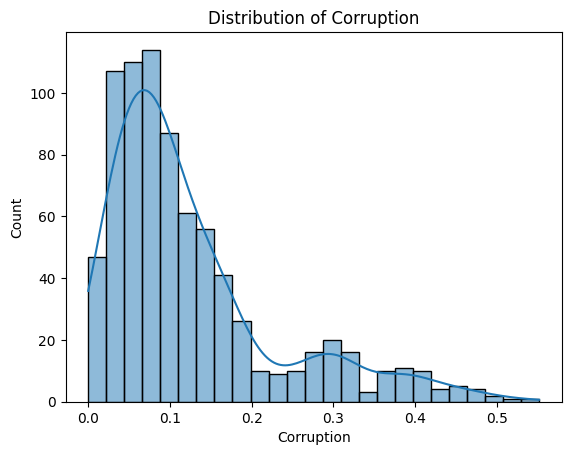

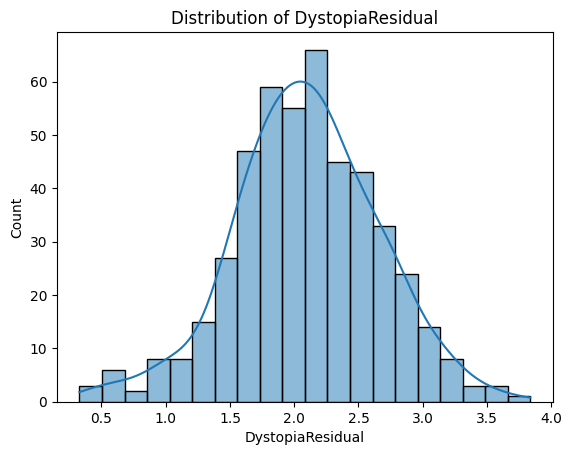

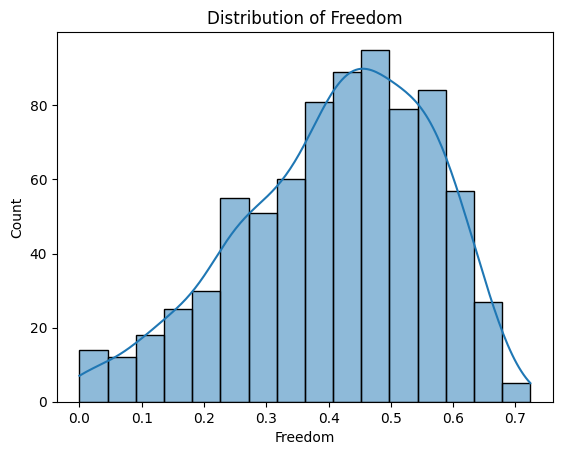

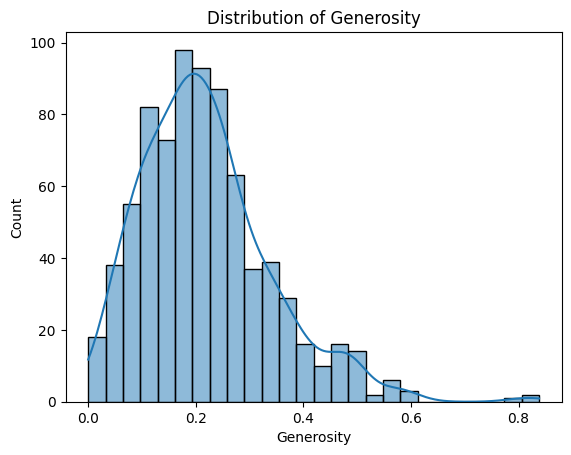

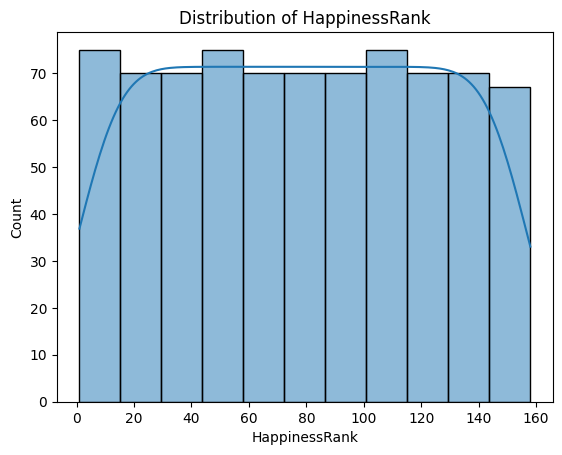

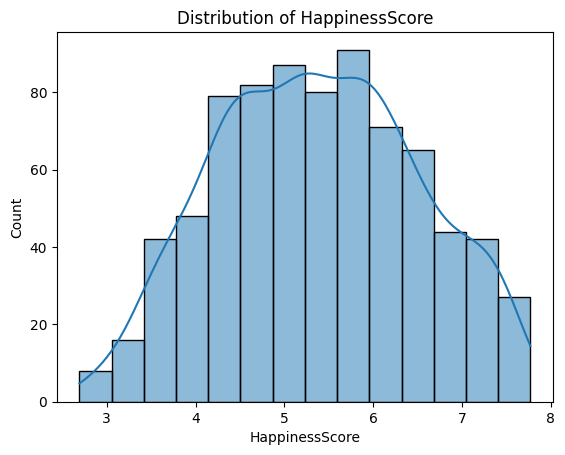

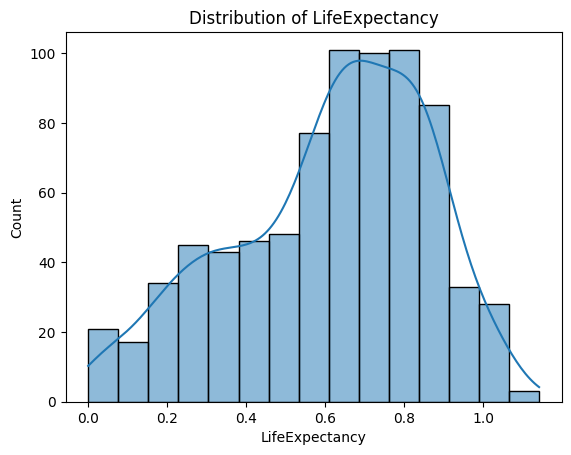

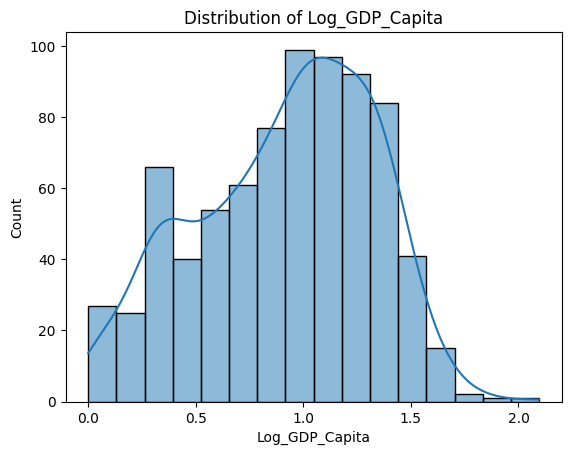

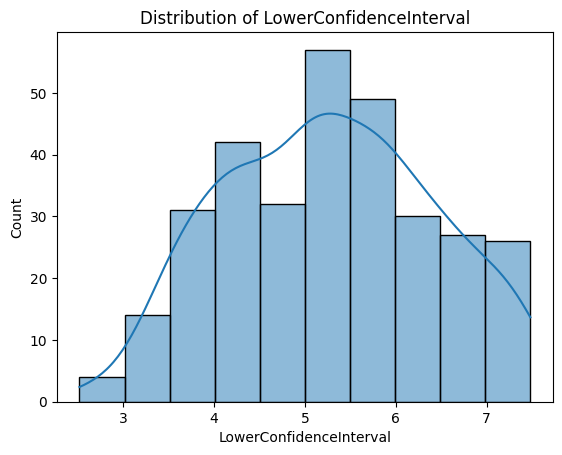

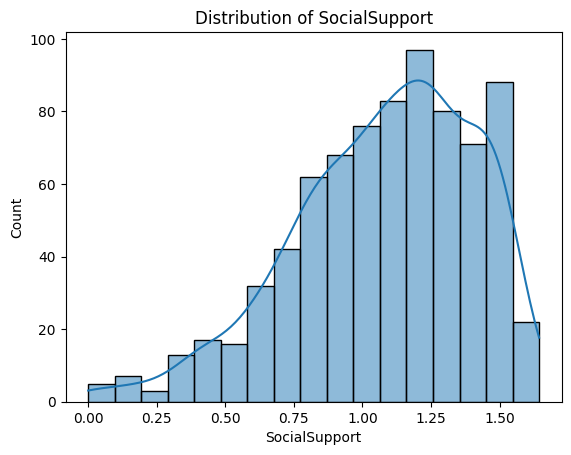

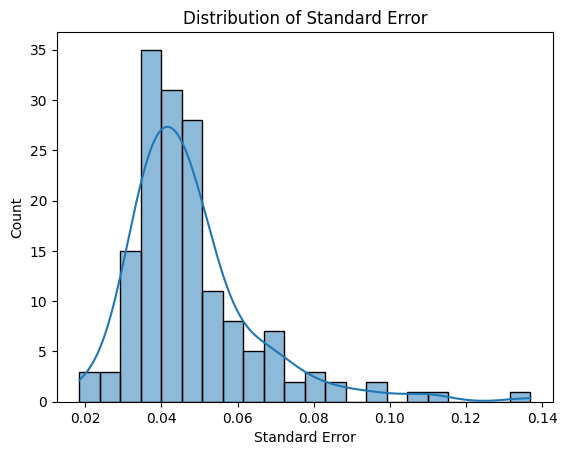

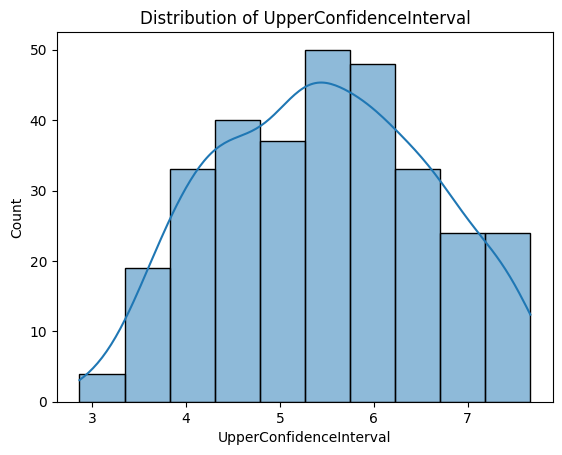

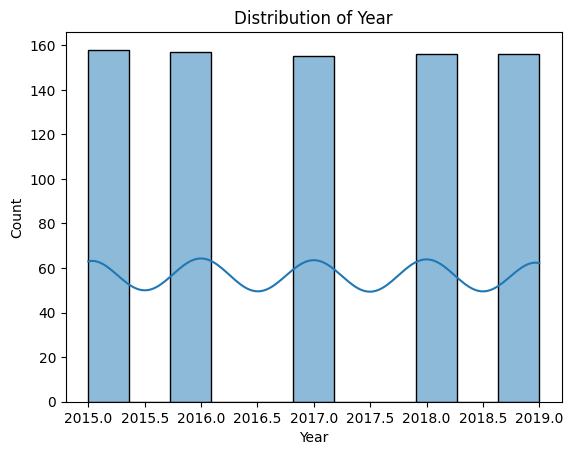

In [41]:
# visuals distributions, differences in df
# two categorical
numeric_features = df.select_dtypes(include= np.number ).columns.tolist()

for col in numeric_features:
    plt.figure()
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


# corruption is messy (country relevant)
# Dystopia res "normal" ( reg)
# freedrom skewed right
# gdp (relative to country/region)
# generosity left
#happiness score uni
# life expeactancy right sk
# social support right

# Cleansing

In [42]:
df["Country"].nunique()

170

In [43]:
# names of countries are inconsitent
# grouping similar strings with rapid fuzz
unique_countries = df["Country"].dropna().unique()
groups = []
seen = set()
th = 70 # threshold

for c in unique_countries:
    if c in seen:
        continue
    group = [other for other in unique_countries if fuzz.ratio(c, other) > th]
    seen.update(group)
    groups.append(group)

#  groups
for g in groups:
    if len(g) > 1:
        print(g)


['Iceland', 'Ireland']
['Australia', 'Austria']
['Argentina', 'Armenia']
['Thailand', 'Taiwan', 'Swaziland']
['Malta', 'Malawi']
['Trinidad and Tobago', 'Trinidad & Tobago']
['Slovakia', 'Slovenia']
['Paraguay', 'Nicaragua']
['Malaysia', 'Malawi']
['North Cyprus', 'Northern Cyprus']
['Algeria', 'Nigeria']
['Mauritius', 'Mauritania']
['Indonesia', 'India']
['Pakistan', 'Tajikistan']
['Zambia', 'Cambodia', 'Namibia', 'Gambia']
['Romania', 'Somalia']
['Serbia', 'Syria']
['Somaliland region', 'Somaliland Region']
['Macedonia', 'North Macedonia']
['Mongolia', 'Angola']
['Ireland', 'Iran', 'Iraq']
['Nigeria', 'Liberia']
['Malawi', 'Mali']
['Nigeria', 'Niger']


In [44]:
# names of countries are still inconsitent
country_map = {

    "Trinidad & Tobago": "Trinidad and Tobago",
    "Northern Cyprus": "North Cyprus",
    "Somaliland Region": "Somaliland region",
    "Taiwan Province of China": "Taiwan",
    "Hong Kong S.A.R., China": "Hong Kong",
    "Congo (Kinshasa)": "Democratic Republic of the Congo",
    "Congo (Brazzaville)": "Republic of the Congo",
    "Ivory Coast": "Cote d'Ivoire",
    "Swaziland": "Eswatini",
    "Macedonia": "North Macedonia",
}

df["Country"] = df["Country"].replace(country_map)

In [45]:
# ensure country names are consistent, region already consistent
df["Country"] = df["Country"].str.strip().str.title()

In [46]:
# check for missing values and correct data types
display(df.isna().sum())
display(df.dtypes)

,0
Corruption,1
Country,0
Country_Short,626
Country_Year,626
DystopiaResidual,312
Freedom,0
Generosity,0
HappinessRank,0
HappinessScore,0
LifeExpectancy,0


,0
Corruption,float64
Country,object
Country_Short,object
Country_Year,object
DystopiaResidual,float64
Freedom,float64
Generosity,float64
HappinessRank,int64
HappinessScore,float64
LifeExpectancy,float64


Context:
The features represent coefficients from a regression-based model used to decompose the Happiness Score. As a result, they are already scaled, with all values falling between 0 and 1. The variables Happiness Score, Happiness Rank, and Year are outside of this model. Given the skewed distributions, if these features were to be used in a predictive modeling context, additional preprocessing such as normalization or standardization could be applied, depending on whether the chosen algorithm assumes normality.

To illustrate this, we demonstrate the use of the Shapiro–Wilk test and the Box–Cox transformation using the residual-related variables. The column “Dystopia Residuals” represents the unexplained component of the regression model combined with a baseline value referred to as Dystopia. This baseline is computed by plugging in the lowest observed values for each factor to obtain a minimum reference point, rather than using an intercept, since variables such as GDP per capita cant be zero.



In [47]:
# Impute missing value in 'Corruption' column with its mean
df['Corruption'].fillna(df['Corruption'].mean(), inplace=True)

# calculate missing values based on publicly available formula
#“Dystopia” is a hypothetical country with the lowest observed values for all factors

df["DystopiaResidual"] = df["HappinessScore"] - (df["Log_GDP_Capita"] + df["SocialSupport"] + df["LifeExpectancy"] +
                        df["Freedom"] + df["Generosity"] + df["Corruption"]
)
df["DystopiaResidual"].isna().sum()

np.int64(0)

In [48]:
display(df["Region"].unique())

array(['Western Europe', 'North America', 'Australia and New Zealand',
       'Middle East and Northern Africa', 'Latin America and Caribbean',
       'Southeastern Asia', 'Central and Eastern Europe', 'Eastern Asia',
       'Sub-Saharan Africa', 'Southern Asia', nan], dtype=object)

In [49]:
# missing values in region
# some may be not in the mapping for regions in df2015

missing_region_map = {
    "Belize": "Latin America and Caribbean",
    "Somalia": "Sub-Saharan Africa",
    "Namibia": "Sub-Saharan Africa",
    "South Sudan": "Sub-Saharan Africa",
    "Trinidad And Tobago": "Latin America and Caribbean",
    "North Macedonia": "Central and Eastern Europe",
    "Gambia": "Sub-Saharan Africa"
}
df['Region'] = df['Region'].fillna(df['Country'].map(missing_region_map))


In [50]:
# Standard Error only in 1 df and Confidence Intervals are only present in 2 dfs.
# we dont have other variables to impute these values or calculuate them
# dropping SE and CIs columns

df.drop(columns=["LowerConfidenceInterval", "UpperConfidenceInterval"], inplace=True, axis = 1)
df.drop("Standard Error", inplace=True, axis = 1)
df.columns

Index(['Corruption', 'Country', 'Country_Short', 'Country_Year',
       'DystopiaResidual', 'Freedom', 'Generosity', 'HappinessRank',
       'HappinessScore', 'LifeExpectancy', 'Log_GDP_Capita', 'Region',
       'SocialSupport', 'Year'],
      dtype='object')

In [51]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

In [52]:
df[df.isna().any(axis=1)]


,Corruption,Country,Country_Short,Country_Year,DystopiaResidual,Freedom,Generosity,HappinessRank,HappinessScore,LifeExpectancy,Log_GDP_Capita,Region,SocialSupport,Year
0,0.41978,Switzerland,NaN,NaN,2.51742,0.66557,0.29678,1,7.587,0.94143,1.39651,Western Europe,1.34951,2015
1,0.14145,Iceland,NaN,NaN,2.70209,0.62877,0.43630,2,7.561,0.94784,1.30232,Western Europe,1.40223,2015
2,0.48357,Denmark,NaN,NaN,2.49196,0.64938,0.34139,3,7.527,0.87464,1.32548,Western Europe,1.36058,2015
3,0.36503,Norway,NaN,NaN,2.46509,0.66973,0.34699,4,7.522,0.88521,1.45900,Western Europe,1.33095,2015
4,0.32957,Canada,NaN,NaN,2.45182,0.63297,0.45811,5,7.427,0.90563,1.32629,North America,1.32261,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
622,0.09700,Tanzania,NaN,NaN,0.62800,0.48100,0.27000,153,3.303,0.38100,0.45500,Sub-Saharan Africa,0.99100,2018
623,0.10600,South Sudan,NaN,NaN,1.69000,0.11200,0.22400,154,3.254,0.17700,0.33700,Sub-Saharan Africa,0.60800,2018
624,0.03800,Central African Republic,NaN,NaN,2.48800,0.30500,0.21800,155,3.083,0.01000,0.02400,Sub-Saharan Africa,0.00000,2018
625,0.07600,Burundi,NaN,NaN,1.75200,0.06500,0.14900,156,2.905,0.14500,0.09100,Sub-Saharan Africa,0.62700,2018


In [53]:
# check for outliers using IQR
numeric_features = df.select_dtypes(include= np.number ).columns.tolist()
def outliers_iqr(df, columns):
    outlier_summary = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outlier_summary[col] = len(outliers)
    return pd.Series(outlier_summary).sort_values(ascending=False)

outliers_iqr(df, numeric_features)


,0
Corruption,68
DystopiaResidual,19
Generosity,17
SocialSupport,10
HappinessRank,0
Freedom,0
HappinessScore,0
LifeExpectancy,0
Log_GDP_Capita,0
Year,0


In [54]:
# testing for normal distrbution
# Shapiro-Wilk Test
cols_to_test = df[numeric_features].drop(columns = ["HappinessRank", "Year"])
for col in cols_to_test:

  shapiro_result = shapiro(df[col])
  if shapiro_result.pvalue > 0.05:
      print(f"Shapiro-Wilk Test for {col}:")
      print(f"{shapiro_result}")
      print("The data is normally distributed. \n")
  else:
      print(f"Shapiro-Wilk Test for {col}:")
      print(f"{shapiro_result}")
      print("The data is not normally distributed. \n ")

Shapiro-Wilk Test for Corruption:
ShapiroResult(statistic=np.float64(0.8386255527685847), pvalue=np.float64(2.06712459611163e-27))
The data is not normally distributed. 
 
Shapiro-Wilk Test for DystopiaResidual:
ShapiroResult(statistic=np.float64(0.9938227795382197), pvalue=np.float64(0.00267548384289317))
The data is not normally distributed. 
 
Shapiro-Wilk Test for Freedom:
ShapiroResult(statistic=np.float64(0.9719098789403495), pvalue=np.float64(4.0796295489239105e-11))
The data is not normally distributed. 
 
Shapiro-Wilk Test for Generosity:
ShapiroResult(statistic=np.float64(0.945447455156983), pvalue=np.float64(2.2435168510490684e-16))
The data is not normally distributed. 
 
Shapiro-Wilk Test for HappinessScore:
ShapiroResult(statistic=np.float64(0.9851614606014464), pvalue=np.float64(4.043064635616728e-07))
The data is not normally distributed. 
 
Shapiro-Wilk Test for LifeExpectancy:
ShapiroResult(statistic=np.float64(0.9664987013545899), pvalue=np.float64(2.1122405048829015

In [55]:
df.isna().sum()

,0
Corruption,0
Country,0
Country_Short,626
Country_Year,626
DystopiaResidual,0
Freedom,0
Generosity,0
HappinessRank,0
HappinessScore,0
LifeExpectancy,0


Shapiro-Wilk Test for Corruption:


ShapiroResult(statistic=np.float64(0.985054702153918), pvalue=np.float64(3.6945043223719135e-07))

The data is not normally distributed. 

Shapiro-Wilk Test for DystopiaResidual:


ShapiroResult(statistic=np.float64(0.9964210872518742), pvalue=np.float64(0.07392056356160637))

The data is normally distributed. 

Shapiro-Wilk Test for Freedom:


...

The data is not normally distributed. 

Shapiro-Wilk Test for Log_GDP_Capita:


ShapiroResult(statistic=np.float64(0.972249447179388), pvalue=np.float64(4.9712653606951576e-11))

The data is not normally distributed. 

Shapiro-Wilk Test for SocialSupport:


ShapiroResult(statistic=np.float64(0.9753074838341176), pvalue=np.float64(3.172227405160421e-10))

The data is not normally distributed. 

plot of Dystopia Residuals before and after transformation:


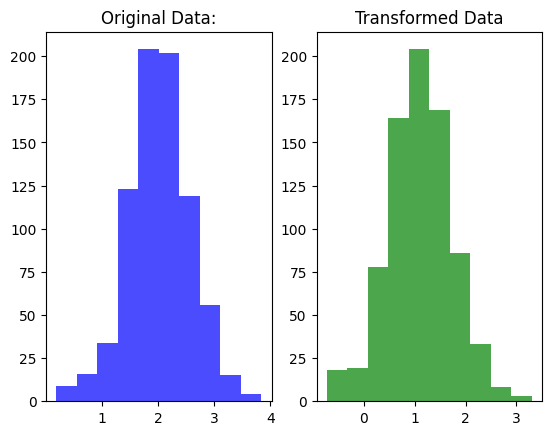

In [56]:
# residuals are not normal dist. as per shapiro test.
#  we use the Box-Cox
# add a small constant to avoid 0s
for col in cols_to_test:
  transformed_data, lambda_boxycoxy = boxcox(df[col] + 0.0001)

  if shapiro(transformed_data).pvalue > 0.05:
      print(f"Shapiro-Wilk Test for {col}:")
      display(shapiro(transformed_data))
      print("The data is normally distributed. \n")
  else:
      print(f"Shapiro-Wilk Test for {col}:")
      display(shapiro(transformed_data))
      print("The data is not normally distributed. \n")

# plot of Dystopia Residuals
transformed_data2, lambda_boxycoxy = boxcox(df['DystopiaResidual'] + 0.0001)
print("plot of Dystopia Residuals before and after transformation:")
plt.figure()

plt.subplot(1, 2, 1)
plt.hist(df["DystopiaResidual"], color='blue', alpha=0.7)
plt.title('Original Data:')

plt.subplot(1, 2, 2)
plt.hist(transformed_data2, color='green', alpha=0.7)
plt.title('Transformed Data')

plt.show()
# not normal but better

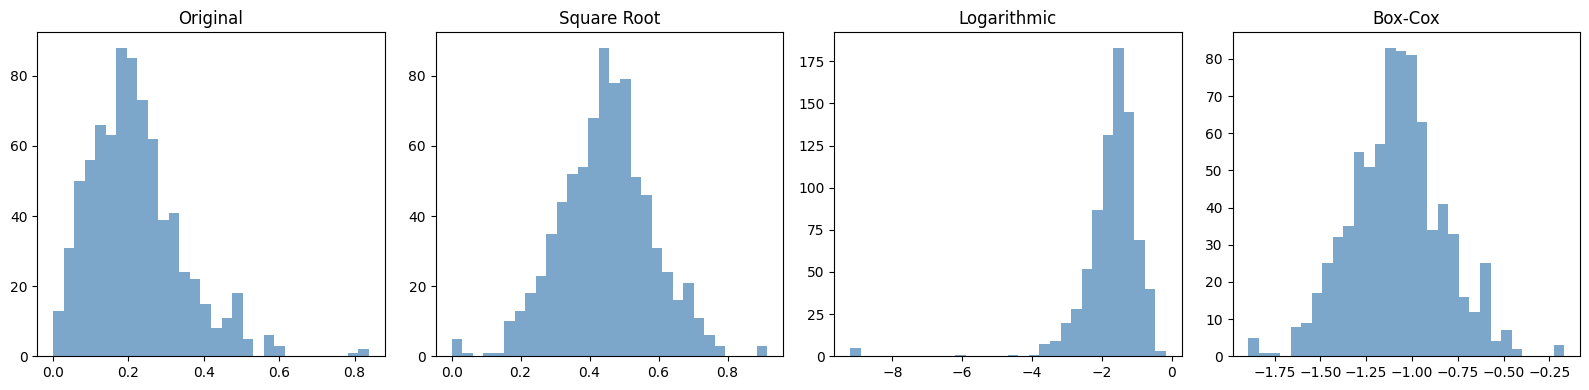

In [57]:
# Compare sqrt, log, and Box-Cox on Generosity
col = "Generosity"
sqrt_transformed = np.sqrt(df[col])
log_transformed = np.log(df[col] + 0.0001)
boxcox_transformed, _ = boxcox(df[col] + 0.0001)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, data, title in zip(axes,
    [df[col], sqrt_transformed, log_transformed, boxcox_transformed],
    ["Original", "Square Root", "Logarithmic", "Box-Cox"]):
    ax.hist(data, bins=30, color="steelblue", alpha=0.7)
    ax.set_title(title)
plt.tight_layout()
plt.show()

# Enrichment

In [58]:
# Creating new features by aggregation
# map regions to their contintents
region_to_continent = {
    'Western Europe': 'Europe',
    'Central and Eastern Europe': 'Europe',
    'Eastern Asia': 'Asia',
    'Southeastern Asia': 'Asia',
    'Southern Asia': 'Asia',
    'Middle East and Northern Africa': 'Africa',
    'Sub-Saharan Africa': 'Africa',
    'North America': 'North America',
    'Latin America and Caribbean': 'South America',
    'Australia and New Zealand': 'Oceania',
}
df['Continent'] = df['Region'].map(region_to_continent)

# Expected happiness from components
df['Expected_Happiness'] = df['HappinessScore'] - df["DystopiaResidual"] # kernel issue?

# Difference between actual and expected
df['Happiness_vs_Expected'] = df['HappinessScore'] - df['Expected_Happiness']

Since most of the features are coefficients, engineering additional features from them would not be meaningful. However, if we extend the context, we could derive further descriptive features. The dataset includes survey results from 2015 to 2016, with one observation per country per year. To better explore trends over time, we pivot the table to display each country’s survey results across the years.



In [59]:
# binning HappinessScore into Low / Medium / High
df["Happiness_Tier"] = pd.cut(
    df["HappinessScore"],
    bins=3,
    labels=["Low", "Medium", "High"]
)
print(df["Happiness_Tier"].value_counts())

Happiness_Tier
Medium    394
High      222
Low       166
Name: count, dtype: int64


In [60]:
# Pivot table by year
static_cols = ['Region', 'Continent','Country'] # time invariate
static_info = df[static_cols].drop_duplicates(subset='Country')

# Define features to be pivoted, excluding 'Year'
pivot_values = [col for col in numeric_features if col != 'Year']

pivot_df = df.pivot_table(
    index='Country',
    columns='Year',
    values=pivot_values
)
# flatten columns
pivot_df.columns = [f"{col[0]}_{col[1]}" for col in pivot_df.columns]
pivot_df.reset_index(inplace=True)

pivot_df = pivot_df.merge(static_info, on='Country', how='left')
pivot_df.columns

Index(['Country', 'Corruption_2015', 'Corruption_2016', 'Corruption_2017',
       'Corruption_2018', 'Corruption_2019', 'DystopiaResidual_2015',
       'DystopiaResidual_2016', 'DystopiaResidual_2017',
       'DystopiaResidual_2018', 'DystopiaResidual_2019', 'Freedom_2015',
       'Freedom_2016', 'Freedom_2017', 'Freedom_2018', 'Freedom_2019',
       'Generosity_2015', 'Generosity_2016', 'Generosity_2017',
       'Generosity_2018', 'Generosity_2019', 'HappinessRank_2015',
       'HappinessRank_2016', 'HappinessRank_2017', 'HappinessRank_2018',
       'HappinessRank_2019', 'HappinessScore_2015', 'HappinessScore_2016',
       'HappinessScore_2017', 'HappinessScore_2018', 'HappinessScore_2019',
       'LifeExpectancy_2015', 'LifeExpectancy_2016', 'LifeExpectancy_2017',
       'LifeExpectancy_2018', 'LifeExpectancy_2019', 'Log_GDP_Capita_2015',
       'Log_GDP_Capita_2016', 'Log_GDP_Capita_2017', 'Log_GDP_Capita_2018',
       'Log_GDP_Capita_2019', 'SocialSupport_2015', 'SocialSupport_2016

In [61]:
# External source: map every region to a development classification
df_dev = df[["Region"]].drop_duplicates().copy()
df_dev["Dev_Class"] = ["Developed", "Developing", "Developed", "Developing",
                        "Developing", "Developing", "Developing", "Developing",
                        "Developed", "Developed","Developing"]

for how in ["inner", "left", "right", "outer"]:
    result = df.merge(df_dev, on="Region", how=how)
    print(f"{how}: {result.shape[0]} rows")
    display(result[["Country", "Region", "Dev_Class"]].head(3))

inner: 782 rows


,Country,Region,Dev_Class
0,Switzerland,Western Europe,Developed
1,Iceland,Western Europe,Developed
2,Denmark,Western Europe,Developed


left: 782 rows


,Country,Region,Dev_Class
0,Switzerland,Western Europe,Developed
1,Iceland,Western Europe,Developed
2,Denmark,Western Europe,Developed


right: 782 rows


,Country,Region,Dev_Class
0,Switzerland,Western Europe,Developed
1,Iceland,Western Europe,Developed
2,Denmark,Western Europe,Developed


outer: 782 rows


,Country,Region,Dev_Class
0,New Zealand,Australia and New Zealand,Developed
1,Australia,Australia and New Zealand,Developed
2,New Zealand,Australia and New Zealand,Developed


In [62]:
# For demonstation, use of Bernoulli RBM model to create new features
# define features
numeric_features = ['HappinessScore', 'Log_GDP_Capita', 'Freedom', 'SocialSupport', 'Generosity', 'Corruption']
categorical_features = ['Region', 'Continent', 'Country']

# most features are already between 0 and 1
# minmax wont change it, but scaling may distort numbers close to 0 or 1

def split_scaling_features(df, numeric_features, lower=0.0, upper=1.0, tol=1e-6):

    scaling = []
    no_scaling = []
    for col in numeric_features:
        cmin, cmax = df[col].min(), df[col].max()
        if (cmin < lower - tol) or (cmax > upper + tol):
            scaling.append(col)
        else:
            no_scaling.append(col)
    return scaling, no_scaling

scaling, no_scaling = split_scaling_features(df, numeric_features)

# preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), scaling), # only features that need scaling (here 1)
        ('passthrough_num', 'passthrough', no_scaling), # features that dont need scaling
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features) # many columns added
])

# combine with rbm and preprocessing
rbm_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('rbm', BernoulliRBM(n_components=5, learning_rate=0.05, n_iter=100, random_state=42))
])

# fit and transform
X = df[numeric_features + categorical_features]
X_rbm = rbm_pipeline.fit_transform(X)

X_rbm[:20]



array([[0.96024604, 0.9577828 , 0.9540364 , 0.99458565, 0.90393561],
       [0.95683918, 0.95461628, 0.95094721, 0.99429332, 0.89667351],
       [0.96006904, 0.95778469, 0.95422551, 0.9944497 , 0.90539654],
       [0.9567598 , 0.95468756, 0.95100721, 0.99423048, 0.89712703],
       [0.88246574, 0.87015433, 0.89064094, 0.73552609, 0.78342752],
       [0.95617487, 0.95360729, 0.9487596 , 0.99388732, 0.89582362],
       [0.95666928, 0.95390892, 0.95055183, 0.99384385, 0.89644789],
       [0.9554319 , 0.95300826, 0.94894525, 0.9941474 , 0.89415011],
       [0.87957801, 0.87498816, 0.88252402, 0.7168796 , 0.78192633],
       [0.87719381, 0.87053585, 0.88003711, 0.7245576 , 0.77704193],
       [0.97837057, 0.97599422, 0.98373651, 0.02682671, 0.97641181],
       [0.94656421, 0.93617443, 0.94107888, 0.9817318 , 0.87267935],
       [0.95547443, 0.95260535, 0.94829887, 0.99388321, 0.89568152],
       [0.9336501 , 0.92179353, 0.92551901, 0.97880967, 0.84942201],
       [0.8647468 , 0.84883594, 0.